<a href="https://colab.research.google.com/github/pranavm716/Reaction-Playground/blob/main/Reaction_Playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Welcome to Reaction Playground! 

This program is written in Python and uses the cheminformatics toolkit *RDKit*. It allows users to experiment with applying common organic reactions to molecules. Scroll down to the "Demo" sections to see how it works!

#Import Statements

In [2]:
%%capture
!pip install rdkit-pypi

# import rdkit components
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdMolDescriptors

# use IPythonConsole for pretty drawings
from rdkit.Chem.Draw import IPythonConsole

## The next line is commented out 
### because GitHub does not render svg's embedded in notebooks
# IPythonConsole.ipython_useSVG=True
IPythonConsole.ipython_useSVG=False

# for flattening tuples and lists
from itertools import chain

# For running BFS
from collections import deque

from google.colab import drive, output
drive.mount('/content/drive')

from PIL import Image, ImageTk
import pdb

#Helper Methods

In [54]:
# A class that holds all the necessary information for a reaction
class Reaction: 
  def __init__(self, name, rxn_list, description, num_reactants) -> None:
    self.name = name
    self.rxn_list = rxn_list
    self.description = description
    self.num_reactants = num_reactants
  
  def get_name(self):
    return self.name
  
  def get_description(self):
    return self.description

  def get_rxn_list(self):
    return self.rxn_list

  def get_num_reactants(self):
    return self.num_reactants
  
  def get_smarts(self):
    return [AllChem.ReactionToSmarts(rxn) for rxn in self.rxn_list]

  def __str__(self):
    return f"{self.name}: {self.get_smarts()}"

# Reads all reactions from file
def preprocess():
  f = open("/content/drive/My Drive/Side Projects/Cheminformatics/Reactions.txt", "r")
  lines = [l.strip() for l in f.readlines()]
  f.close()
  all_rxns = []
  i = 0
  while i < len(lines):
    rxn_name = lines[i]
    i += 1
    rxn_list = []
    while lines[i].startswith("^"):
      rxn_list.append(AllChem.ReactionFromSmarts(lines[i][1:]))
      i += 1
    reactants_side = lines[i-1].index(">")
    num_reactants = lines[i-1][1:reactants_side].count(".") + 1
    rxn_desc = lines[i]
    i += 2

    all_rxns.append(Reaction(rxn_name, rxn_list, rxn_desc, num_reactants))
  
  return all_rxns

# Draws a single molecule on screen
def display_mol(mol):
  display(Draw.MolToImage(mol))

# Draws a grid of molecules on screen
def display_2d_mol_tuple(products):
  for (index, scenario) in enumerate(products, start = 1):
      print(f"Scenario #{index}")
      display(Draw.MolsToGridImage(list(scenario), molsPerRow=len(scenario)))
      print("\n")

# Returns only the unique products in a 2d mol tuple
def generate_unique_products(products):
  smiles = tuple(tuple(Chem.MolToSmiles(s) for s in scenarios) for scenarios in products)
  unique_smiles = tuple(set([tuple(set(x)) for x in smiles]))
  return tuple(tuple(Chem.MolFromSmiles(s) for s in scenarios) for scenarios in unique_smiles) 

# Performs a reaction on a molecule once, and returns a 2d tuple of products
def generate_single_step_product(startMol, rxn, optional_reactants = tuple()):
  products = tuple()
  for r in rxn.get_rxn_list():
    products += r.RunReactants((startMol, ) + optional_reactants)

  return generate_unique_products(products)

# The 2 methods below recursively perform a reaction on a starting molecule and on its products
# until no more products can be formed. Returns the final tuple of products (always 1 x n).
def generate_multi_step_product(startMol, rxn):
  products = generate_multi_step_product_recursion(startMol, rxn, tuple())
  return generate_unique_products((products, ))

def generate_multi_step_product_recursion(startMol, rxn, products):
  single_step_product = generate_single_step_product(startMol, rxn)
  if not single_step_product:
    return (startMol, )
  else:
    for scenario in single_step_product:
      for p in scenario:
        products += generate_multi_step_product_recursion(p, rxn, products)

    return products

# Finds out which reactions are valid for the given molecule 
def find_possible_reactions(startMol, all_rxns, solver_mode = False):
  possible_reactions = []
  for obj in all_rxns:
    if solver_mode and obj.get_num_reactants() > 1: 
      continue # Solver mode will omit any reactions with more than one reactant
    possible_scenarios = []
    for rxn in obj.get_rxn_list():
      rxn_smarts = AllChem.ReactionToSmarts(rxn)
      reactants_side = rxn_smarts[:rxn_smarts.index(">")]
      reactants_side = reactants_side.split(".")
      reaction_match = []
      for mol in reactants_side:
        reaction_match.append(startMol.HasSubstructMatch(Chem.MolFromSmarts(mol)))
      possible_scenarios.append(any(reaction_match))
    possible_reactions.append(any(possible_scenarios))
  possible_indices = [i for (i, val) in enumerate(possible_reactions) if val]
  return possible_indices

# Auto-solver, utilizes multi step products
# Performs breadth first search (BFS) to find the SHORTEST possible reaction pathway to the target molecule
def find_synthetic_pathway(startMol, targetMol, num_steps):
  # Set of visited nodes to prevent loops
  visited = set()
  queue = deque()

  # Add the start_node to the queue and visited list
  queue.append(startMol)
  visited.add(Chem.MolToSmiles(startMol))

  # The format of this dictionary is:
  # key = product SMILES -> value = reactant SMILES
  parent = {}
  parent[Chem.MolToSmiles(startMol)] = None # startMol has no previous reactants

  # The format of this dictionary is:
  # key = (reactant, product) -> value = (rxn_index, choice_index) that converts the reactant into the product
  rxn_and_choices = {} # Needed to reconstruct the reaction pathway later

  # BFS loop
  dist = 0
  path_found = False
  while queue and dist < num_steps:
    for _ in range(len(queue)):
      cur = queue.popleft()
      if Chem.MolToSmiles(cur) == Chem.MolToSmiles(targetMol):
        path_found = True
        break
      
      possible_indices = find_possible_reactions(cur, all_rxns, solver_mode = True)
      multi_step_products = [generate_multi_step_product(cur, rxn) for rxn in [all_rxns[i] for i in possible_indices]]
      for (i, msp) in enumerate(multi_step_products): # Loop through all compatible reactions
        rxn_index = possible_indices[i]
        for (choice_index, mol) in enumerate(msp[0]): # Loop through all products of each compatible reaction
          if Chem.MolToSmiles(mol) not in visited:
            visited.add(Chem.MolToSmiles(mol))
            queue.append(mol)

            parent[Chem.MolToSmiles(mol)] = Chem.MolToSmiles(cur)
            rxn_and_choices[(Chem.MolToSmiles(cur), Chem.MolToSmiles(mol))] = (rxn_index, choice_index)
    if path_found: 
      break
    dist += 1

  # Reconstructing the reaction pathway
  rxn_pathway = []
  choice_pathway = []
  targetSmiles = Chem.MolToSmiles(targetMol)    
  if path_found:
    while parent[targetSmiles] is not None:
      rxn_index, choice_index = rxn_and_choices[(parent[targetSmiles], targetSmiles)]
      rxn_pathway.append(rxn_index)
      choice_pathway.append(choice_index)
      targetSmiles = parent[targetSmiles]

    rxn_pathway.reverse()
    choice_pathway.reverse()

  return path_found, rxn_pathway, choice_pathway

#The Main Program Loop

In [55]:
def run_program():
  multi_step_react_mode = True # Can be set by the user
  solver_mode = False
  num_steps = 15

  startSMILES = input("Enter the SMILES of the starting molecule: ")
  startMol = Chem.MolFromSmiles(startSMILES)

  if input("Would you like to input a target molecule? (y/n): ") == "y":
    solver_mode = True
    targetSMILES = input("Enter the SMILES of the target molecule: ")
    targetMol = Chem.MolFromSmiles(targetSMILES)

  history = [startMol]

  # If the user inputs a target molecule, the code block below will run the solving algorithm (Demo 2)
  proceed_after = True
  if solver_mode:    
    path_found, rxn_pathway, choice_pathway = find_synthetic_pathway(startMol, targetMol, num_steps)    

    print("\nThe goal is to find a reaction pathway that converts the molecule on the left into the molecule on the right.")
    display(Draw.MolsToGridImage([startMol, targetMol]))

    if path_found:
      startMolcpy = Chem.MolFromSmiles(Chem.MolToSmiles(startMol))
      print(f"\n{len(rxn_pathway)}-step synthetic pathway found!\n\nThis is your starting molecule:")
      for (i, rxn_index) in enumerate(rxn_pathway):
        display_mol(startMolcpy)
        print(f"\nStep #{i + 1} - {all_rxns[rxn_index].get_name()}.", end= " ")
        multi_step_product = generate_multi_step_product(startMolcpy, all_rxns[rxn_index])
        choice = choice_pathway[i]
        startMolcpy = Chem.MolFromSmiles(Chem.MolToSmiles(multi_step_product[0][choice]))

        num_products = len(multi_step_product[0])
        if num_products > 1:          
          print(f"This produces {num_products} products:")
          display(Draw.MolsToGridImage(list(multi_step_product[0]), molsPerRow = num_products))
          print(f"\nPick product #{choice + 1}:")
        else:
          print("The product is:")
      display_mol(startMolcpy)
      print("This is your target molecule.")
    else:
      print(f"\nNo synthetic pathway found in {num_steps} steps. It is also possible that no synthetic pathway exists at all.")

    if input("\nWould you like to continue using Reaction Playground (y/n)? ") == "y":
      print("\nThis is your starting molecule:\n")
    else:
      proceed_after = False

  # The while loop below is the playground mode (Demo 1)
  while proceed_after:
    display_mol(startMol)
    print(f"Smiles of molecule: {Chem.MolToSmiles(startMol)}")

    possible_indices = find_possible_reactions(startMol, all_rxns)
    
    if possible_indices:
      print("\nCompatible reactions are listed below. Choose a reaction:\n")
      [print(f"[{index}] {all_rxns[i].get_name()}\n{all_rxns[i].get_description()}\n") for (index, i) in enumerate(possible_indices, start = 1)]
    else:
      print("\nThere are no compatible reactions.\n")

    back_allowed = len(history) > 1
    if back_allowed:
      print("[b] Back\n")
    print("[q] Quit\n")

    choice = input()
    if choice == "q":
      break
    elif back_allowed and choice == "b":
      startMol = history[-2]
      del history[-1]
      continue
    elif choice in [str(x + 1) for x in range(len(possible_indices))]:
      choice = int(choice) - 1
      choice = possible_indices[choice]
    else:
      print("Invalid input!")
      continue

    rxn = all_rxns[choice]

    # Handling the reactions that require additional reactants (need to prompt user)
    if rxn.get_num_reactants() > 1:
      optional_reactants = ()
      isFirstReactant = startMol.HasSubstructMatch(Chem.MolFromSmarts(rxn.get_smarts()[0].split(".")[0]))
      swap_reactants = False
      if rxn.get_name() == "Grignard reaction":
        if isFirstReactant:
          query = input("\nEnter the SMILES of CO2, or an aldehyde, ketone, or nitrile: ")
        else:
          query = input("\nEnter the SMILES of the carbon nucleophile: ")
          swap_reactants = True
      elif rxn.get_name() == "Fischer esterification":
        if isFirstReactant:
          query = input("\nEnter the SMILES of the alcohol: ")
        else:
          query = input("\nEnter the SMILES of the carboxylic acid: ")
          swap_reactants = True
      elif rxn.get_name() == "Amide synthesis from acid chloride":
        if isFirstReactant:
          query = input("\nEnter the SMILES of ammonia or an amine: ")
        else:
          query = input("\nEnter the SMILES of the acid chloride: ")
          swap_reactants = True
      elif rxn.get_name() == "Ester synthesis from acid chloride":
        if isFirstReactant:
          query = input("\nEnter the SMILES of the primary alcohol: ")
        else:
          query = input("\nEnter the SMILES of the acid chloride: ")
          swap_reactants = True

      second_reactant = Chem.MolFromSmiles(query)
      print("\nYou entered:")
      display_mol(second_reactant)
      print()
      optional_reactants += (second_reactant, )

      if swap_reactants:
        products = generate_single_step_product(optional_reactants[0], rxn, (startMol, ))
      else:
        products = generate_single_step_product(startMol, rxn, optional_reactants)

    elif not multi_step_react_mode:
      products = generate_single_step_product(startMol, rxn)
    else:
      products = generate_multi_step_product(startMol, rxn)
    
    if not products:
      print("\nNo reaction!\n")
      continue

    print()
    if len(products[0]) > 1:
      print("The products are:")
    else:
      print("The product is:")

    if len(products) > 1:
      display_2d_mol_tuple(products)

    scenario_picked = 0
    if len(products) > 1:
      scenario_picked = int(input(f"\nPick a scenario to analyze next (1 - {len(products)}): ")) - 1

    if len(products[scenario_picked]) > 1:
      display(Draw.MolsToGridImage(list(products[scenario_picked]), molsPerRow = len(products[scenario_picked])))
      prod_picked = int(input(f"\nPick a product to analyze next (1 - {len(products[scenario_picked])}): ")) - 1
      startMol = products[scenario_picked][prod_picked]
    else:
      startMol = products[scenario_picked][0]

    startMol = Chem.MolFromSmiles(Chem.MolToSmiles(startMol))
    history.append(startMol)

#List of Available Reactions

All of the reactions are read in from a text file. Reactions are represented using a standard known as SMARTS (see the link in the references section). You can view the reactions text file here:
https://drive.google.com/file/d/19FOclyvEkH0uFV2wiXeHjnjK9J4OfTq9/view?usp=sharing

In [56]:
all_rxns = preprocess()
for rxn in all_rxns:
  print(rxn.get_name())
  print(f"- {rxn.get_description()}\n")

Hydrolysis of esters, amides, and nitriles
- Hydrolizes esters/amides/nitriles into carboxylic acids.

DMP/PCC oxidation of alcohols
- Converts primary alcohols to aldehydes and secondary alcohols to ketones.

H2CrO4 (chromic acid) oxidation of alcohols and aldehydes
- Converts primary alcohols and aldehydes to carboxylic acids; and secondary alcohols to ketones.

NaBH4 (sodium borohydride) reduction of aldehydes and ketones
- Converts aldehydes and ketones to primary alcohols.

LiAlH4 (lithium aluminum hydride) reduction of aldehyes, ketones, esters, carboxylic acids, amides, and nitriles
- Converts aldehydes, esters, and carboxylic acids to primary alcohols; ketones to secondary alcohols; and amides/nitriles to amines.

PBr3 bromination of alcohols
- Converts primary and secondary alcohols into alkyl bromides.

Ozonolysis
- Cleaves alkenes/alkynes into carbonyls.

NaCN (sodium cyanide) nitrile synthesis
- Converts a primary/secondary alkyl bromides into nitriles via SN2.

Oxymercurat

#Demo 1: Playground Mode

This mode allows a user to enter a molecule and apply compatible reactions to it to generate products. The user can keep repeating this process for as long as they wish.

Note: Computers represent molecules using a common standard called SMILES. You can find the SMILES code for any molecule by drawing it on this website:
http://www.cheminfo.org/flavor/malaria/Utilities/SMILES_generator___checker/index.html

Alternatively, if you know the name of the molecule, you can find its SMILES by searching it in any chemical database.

Enter the SMILES of the starting molecule: C/C=C/C=C(CC)/C1CC1
Would you like to input a target molecule? (y/n): n


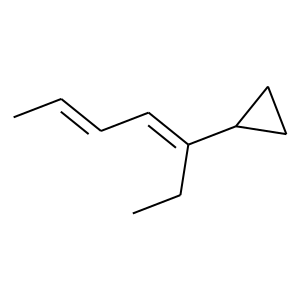

Smiles of molecule: C/C=C/C=C(\CC)C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] Ozonolysis
Cleaves alkenes/alkynes into carbonyls.

[2] Oxymercuration/demercuration (OM/DM)
Attaches an -OH group to the more substituted carbon atom of an alkene (Markovnikov addition).

[3] Hydroboration/oxidation (BH3/[O])
Attaches an -OH group to the less substituted carbon atom of an alkene (Anti-Markovnikov addition).

[q] Quit

1

The products are:


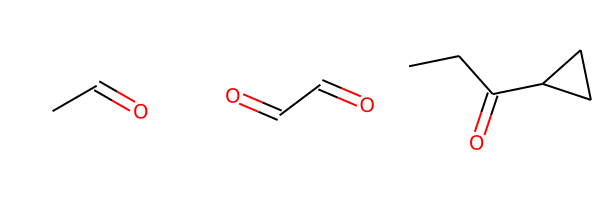


Pick a product to analyze next (1 - 3): 3


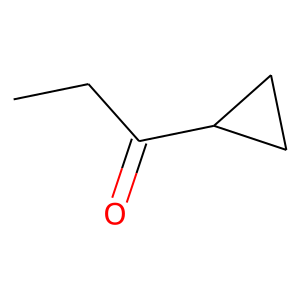

Smiles of molecule: CCC(=O)C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] NaBH4 (sodium borohydride) reduction of aldehydes and ketones
Converts aldehydes and ketones to primary alcohols.

[2] LiAlH4 (lithium aluminum hydride) reduction of aldehyes, ketones, esters, carboxylic acids, amides, and nitriles
Converts aldehydes, esters, and carboxylic acids to primary alcohols; ketones to secondary alcohols; and amides/nitriles to amines.

[3] Grignard reaction
Converts a carbon nucleophile + (formaldehyde/aldehydes/ketones into primary/secondary/tertiary alcohols), respectively; or a carbon nucleophile + (nitriles/CO2 into ketones/carboxylic acids), respectively.

[b] Back

[q] Quit

2

The product is:


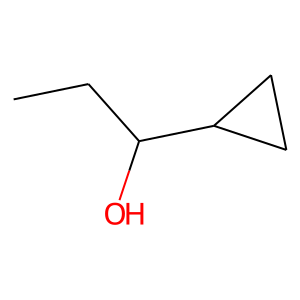

Smiles of molecule: CCC(O)C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] DMP/PCC oxidation of alcohols
Converts primary alcohols to aldehydes and secondary alcohols to ketones.

[2] H2CrO4 (chromic acid) oxidation of alcohols and aldehydes
Converts primary alcohols and aldehydes to carboxylic acids; and secondary alcohols to ketones.

[3] PBr3 bromination of alcohols
Converts primary and secondary alcohols into alkyl bromides.

[4] Fischer esterification
Esterifies a carboxylic acid by reacting it with an alcohol.

[b] Back

[q] Quit

3

The product is:


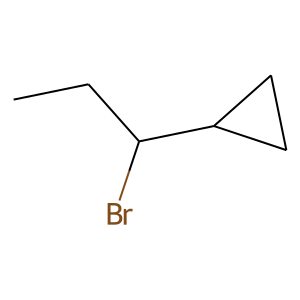

Smiles of molecule: CCC(Br)C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] NaCN (sodium cyanide) nitrile synthesis
Converts a primary/secondary alkyl bromides into nitriles via SN2.

[2] Grignard reagent
Converts an alkyl bromide into a carbon nucleophile for use in Grignard reactions.

[b] Back

[q] Quit

2

The product is:


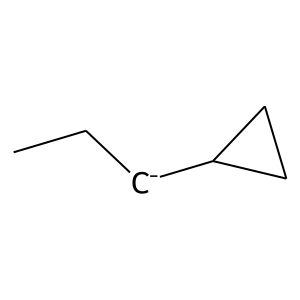

Smiles of molecule: CC[CH-]C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] Grignard reaction
Converts a carbon nucleophile + (formaldehyde/aldehydes/ketones into primary/secondary/tertiary alcohols), respectively; or a carbon nucleophile + (nitriles/CO2 into ketones/carboxylic acids), respectively.

[b] Back

[q] Quit

1

Enter the SMILES of CO2, or an aldehyde, ketone, or nitrile: CCC=O

You entered:


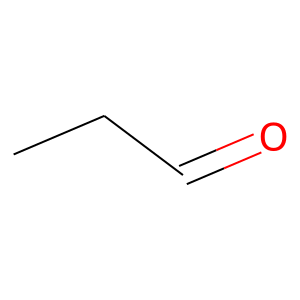



The product is:


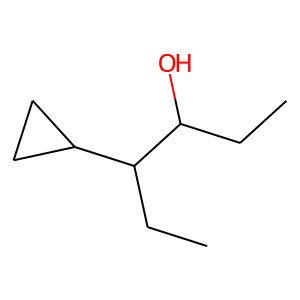

Smiles of molecule: CCC(O)C(CC)C1CC1

Compatible reactions are listed below. Choose a reaction:

[1] DMP/PCC oxidation of alcohols
Converts primary alcohols to aldehydes and secondary alcohols to ketones.

[2] H2CrO4 (chromic acid) oxidation of alcohols and aldehydes
Converts primary alcohols and aldehydes to carboxylic acids; and secondary alcohols to ketones.

[3] PBr3 bromination of alcohols
Converts primary and secondary alcohols into alkyl bromides.

[4] Fischer esterification
Esterifies a carboxylic acid by reacting it with an alcohol.

[b] Back

[q] Quit

q


In [58]:
run_program()

#Demo 2: Synthesis Solver Mode

In this mode, the user enters a target molecule in addition to a starting molecule. The program will execute a breadth first search (BFS) algorithm to try to find a reaction pathway that converts the starting molecule into the target molecule. Additionally, since BFS is being used, the algorithm will find the *shortest* reaction pathway out of all possible ones.


Enter the SMILES of the starting molecule: CC(=O)OC1=CCC(=O)C1
Would you like to input a target molecule? (y/n): y
Enter the SMILES of the target molecule: OCC1CC=C(O)C1

The goal is to find a reaction pathway that converts the molecule on the left into the molecule on the right.


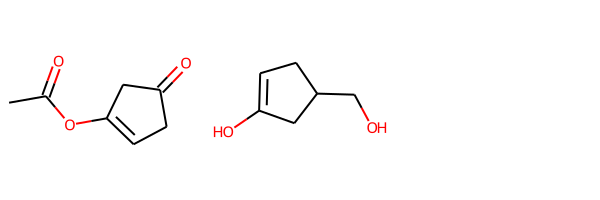


5-step synthetic pathway found!

This is your starting molecule:


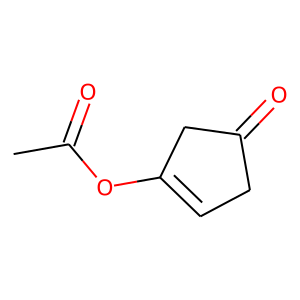


Step #1 - NaBH4 (sodium borohydride) reduction of aldehydes and ketones. The product is:


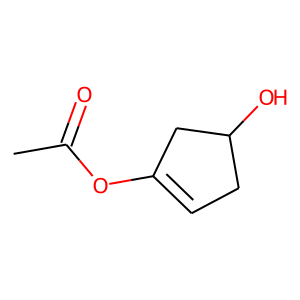


Step #2 - PBr3 bromination of alcohols. The product is:


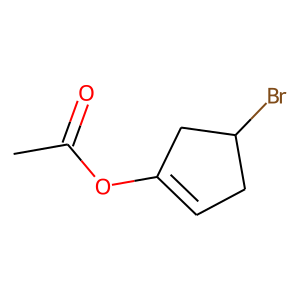


Step #3 - NaCN (sodium cyanide) nitrile synthesis. The product is:


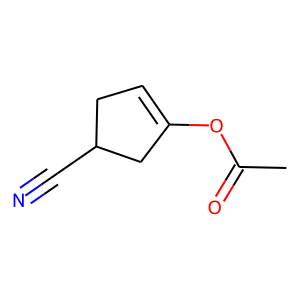


Step #4 - Hydrolysis of esters, amides, and nitriles. This produces 2 products:


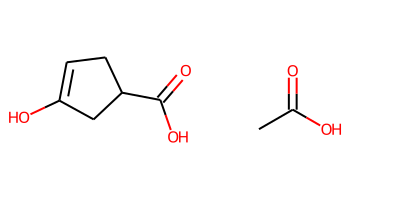


Pick product #1:


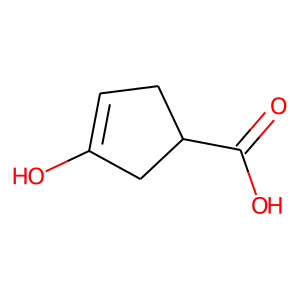


Step #5 - LiAlH4 (lithium aluminum hydride) reduction of aldehyes, ketones, esters, carboxylic acids, amides, and nitriles. The product is:


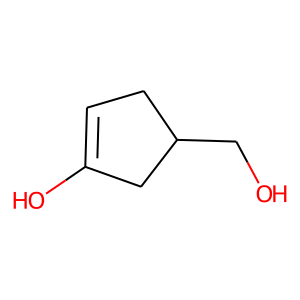

This is your target molecule.

Would you like to continue using Reaction Playground (y/n)? n


In [57]:
run_program()

#Notes


*   Intramolecular reactions do not function properly.
*   Some reactions involving single carbon molecules (methyl-like molecules like methanol, formaldehyde, formic acid, etc.) may not function properly.
* Aromatic reactions (ex. nitration, Friedel-Crafts alkylation/acylation, etc.) have not been implemented yet.



# References


* https://www.rdkit.org/docs/index.html
* https://www.daylight.com/dayhtml/doc/theory/theory.smarts.html
* https://www.daylight.com/dayhtml_tutorials/languages/smarts/smarts_examples.html
* https://github.com/rdkit/rdkit-tutorials/tree/master/notebooks
* https://chem.libretexts.org/
* https://stackabuse.com/courses/graphs-in-python-theory-and-implementation/lessons/breadth-first-search-bfs-algorithm/
* My own organic chemistry notes :)

